Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Using device: cuda
Loading data...
Starting training (with Target Scaling * 100)...
Epoch 1/25, Train Loss: 0.324190, Val Loss: 0.273219
Current LR: 0.0001
Epoch 2/25, Train Loss: 0.322755, Val Loss: 0.274551
Current LR: 0.0001
EarlyStopping counter: 1 out of 7
Epoch 3/25, Train Loss: 0.320908, Val Loss: 0.275241
Current LR: 0.0001
EarlyStopping counter: 2 out of 7
Epoch 4/25, Train Loss: 0.321227, Val Loss: 0.271952
Current LR: 0.0001
Epoch 5/25, Train Loss: 0.319670, Val Loss: 0.273325
Current LR: 0.0001
EarlyStopping counter: 1 out of 7
Epoch 6/25, Train Loss: 0.317233, Val Loss: 0.270283
Current LR: 0.0001
Epoch 7/25, Train Loss: 0.316770, Val Loss: 0.276755
Current LR: 0.0001
EarlyStopping counter: 1 out of 7
Epoch 8/25, Train Loss: 0.317000, Val Loss: 0.272672
Current LR: 0.0001
EarlyStopping counter: 2 out of 7
Epoch 

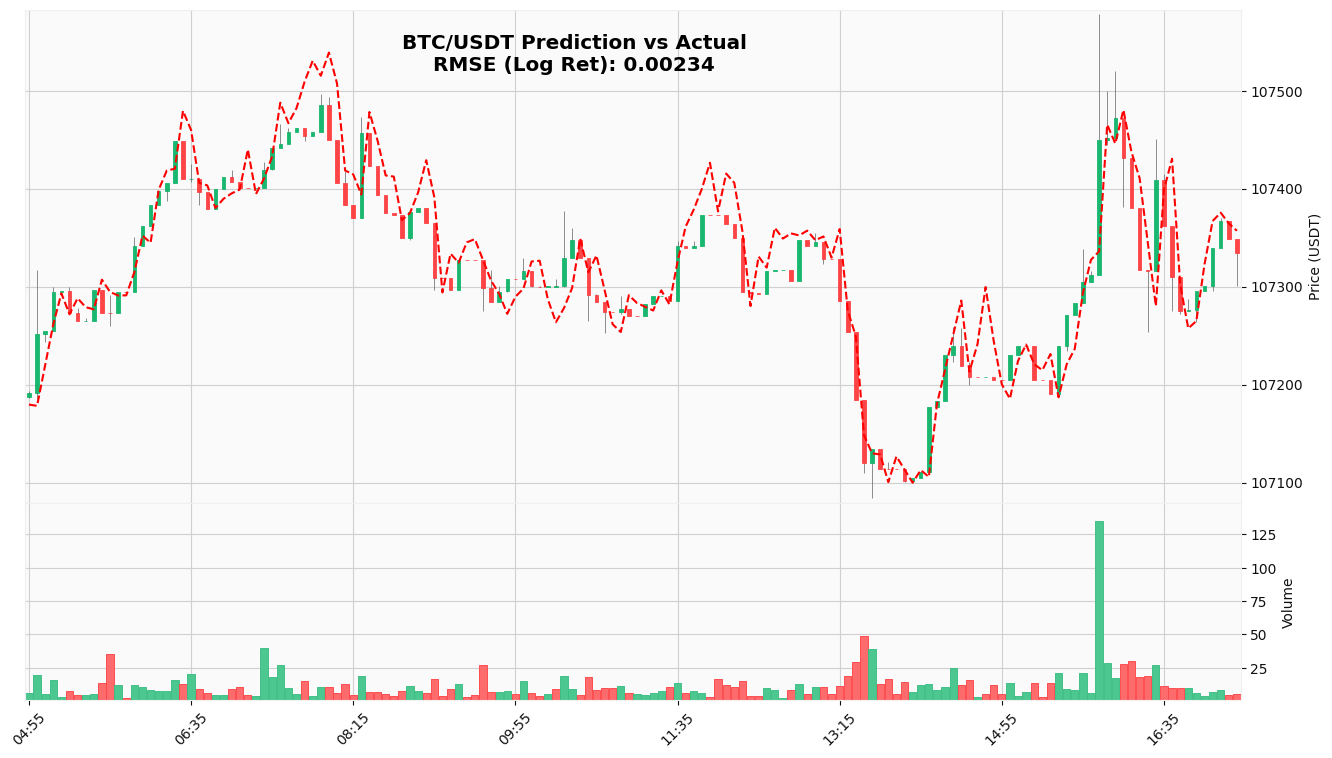

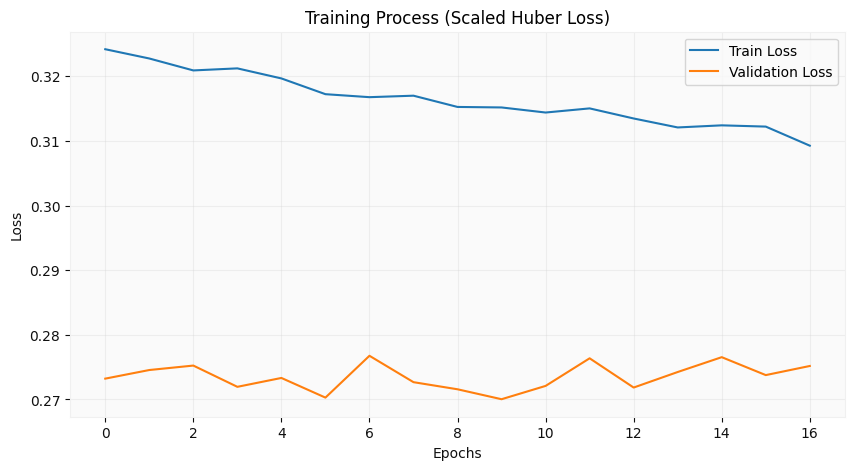

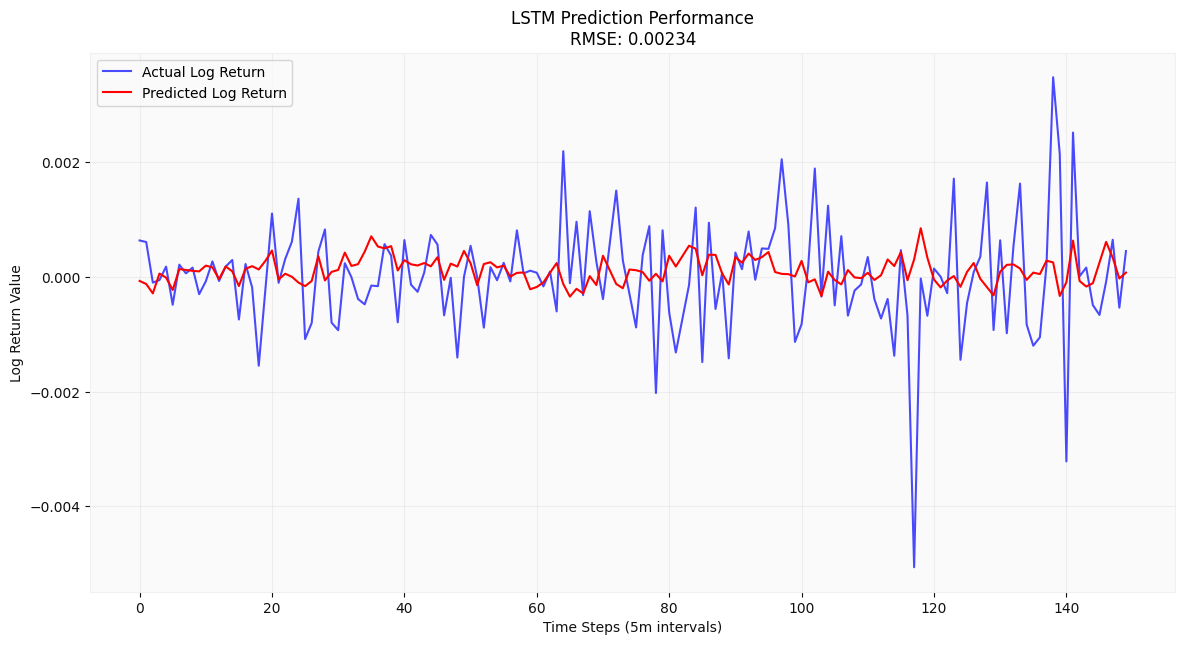

Visualization displayed.


In [4]:
%pip install torch ta mplfinance scikit-learn matplotlib pandas

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mplfinance as mpf
import pandas as pd
from sklearn.preprocessing import StandardScaler
import ta

# --- 1. חיבור לגוגל דרייב (מותאם לקולאב) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
    BASE_DIR = '/content/drive/MyDrive/CryptoProject'
except ImportError:
    print("Not running in Google Colab. Using local directory.")
    BASE_DIR = os.getcwd()

# --- הגדרות נתיבים מעודכנות ---
SYMBOL = 'BTCUSDT'
# עדכון הנתיב למקום החדש שבו שמרנו את הדאטה המעובד
DATA_DIR = os.path.join(BASE_DIR, 'processed_data_lstm', SYMBOL)
MODEL_DIR = os.path.join(BASE_DIR, 'models')

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"Created models directory at: {MODEL_DIR}")

# --- Fine Tuning Hyperparameters ---
BATCH_SIZE = 16        # הקטנו כדי להוסיף רעש חיובי לאימון
EPOCHS = 25
LEARNING_RATE = 0.0001  # הקטנו קצת כדי שהלימוד יהיה עדין יותר
HIDDEN_DIM = 128        # הגדלנו את "המוח" של המודל
NUM_LAYERS = 2
DROPOUT = 0.2
SCALE_FACTOR = 100.0 # ביטלנו את ה-Dropout כדי לא לאבד מידע עדין


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_loss = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'best_lstm_model_{SYMBOL}.pth'))
        self.best_loss = val_loss

def load_data():
    print("Loading data...")
    X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
    y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
    X_val = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
    y_val = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
    X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
    y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
    return X_train, y_train, X_val, y_val, X_test, y_test

def build_demo_loaders(fraction=0.05):
    X_train, y_train, X_val, y_val, X_test, y_test = load_data()

    # Subsample
    train_size = int(len(X_train) * fraction)
    val_size = int(len(X_val) * fraction)
    test_size = int(len(X_test) * fraction)

    X_train = X_train[:train_size]
    y_train = y_train[:train_size]
    X_val = X_val[:val_size]
    y_val = y_val[:val_size]
    X_test = X_test[:test_size]
    y_test = y_test[:test_size]
    return X_train, y_train, X_val, y_val, X_test, y_test


class DirectionalLogCoshLoss(nn.Module):
    def __init__(self, directional_penalty=0.5):
        super(DirectionalLogCoshLoss, self).__init__()
        self.directional_penalty = directional_penalty

    def forward(self, y_pred, y_true):
        # 1. Log-Cosh Loss
        # log(cosh(x)) is smooth and robust to outliers
        loss = torch.log(torch.cosh(y_pred - y_true + 1e-12))

        # 2. Directional Penalty
        # If signs are different, product is negative
        # We penalize when sign(pred) != sign(true)
        penalty = torch.where(y_pred * y_true < 0, self.directional_penalty, 0.0)

        return torch.mean(loss + penalty)

def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    #X_train, y_train, X_val, y_val, X_test, y_test = load_data()
    X_train, y_train, X_val, y_val, X_test, y_test = build_demo_loaders(0.5)

    # --- הטריק: הכפלת המטרה (y) בפקטור ---
    # זה הופך את 0.002 ל-0.2, מספר שהרשת יכולה ללמוד בקלות יותר
    y_train = y_train * SCALE_FACTOR
    y_val = y_val * SCALE_FACTOR
    # את הטסט לא נשנה עכשיו, נטפל בזה בהערכה

    # המרה ל-Tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    # y_test נשאר ב-CPU ובגודל המקורי להשוואה בסוף

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test), batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMModel(input_size=X_train.shape[2], hidden_size=HIDDEN_DIM,
                      num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
    # NEW LOSS FUNCTION
    # 0.5 is the penalty weight; you can increase this to 1.0 if the model still misses directions
    criterion = DirectionalLogCoshLoss(directional_penalty=0.5)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Learning Rate Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    early_stopping = EarlyStopping(patience=7, verbose=True)

    print("Starting training (with Target Scaling * 100)...")
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs.squeeze(), y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]}')

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

    # --- הערכה ---
    print("\nEvaluating on Test Set...")
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'best_lstm_model_{SYMBOL}.pth')))
    model.eval()

    predictions = []
    with torch.no_grad():
        for X_batch, in test_loader: # שים לב: הטסט לא מכיל y בקריאה הזו
            outputs = model(X_batch)
            predictions.extend(outputs.squeeze().cpu().numpy())

    predictions = np.array(predictions)

    # --- חלוקה חזרה בפקטור ---
    # אנחנו מחזירים את התחזית לגודל המקורי כדי להשוות למציאות
    predictions = predictions / SCALE_FACTOR

    # חישוב מדדים על המידע המקורי
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print(f"Final Test RMSE (Original Scale): {rmse:.6f}")

    # 8. Visualization (OHLCV Candles with Predicted Price Overlay)
    print("\nGenerating Candle Visualization...")

    # --- A. Load Original Data for OHLC context ---
    csv_path = os.path.join(BASE_DIR, 'data', 'BTCUSDT_5m_data.csv')
    df_full = pd.read_csv(csv_path)
    df_full['open_time'] = pd.to_datetime(df_full['open_time'])
    df_full.set_index('open_time', inplace=True)

    # --- B. Reconstruct Indices to match Preprocessing.py ---
    # We must replicate the split logic to find exactly which candles are in the Test Set
    # Note: Ensure these match the constants in Preprocessing.py
    SEQ_LENGTH = 120
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1

    n = len(df_full)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    # The test set in Preprocessing starts at val_end
    # But the first TARGET (y) appears after SEQ_LENGTH steps
    test_start_index = val_end + SEQ_LENGTH

    # Slice the original dataframe to match the size of 'predictions'
    # We limit it to the number of predictions we actually have
    df_test_candles = df_full.iloc[test_start_index : test_start_index + len(predictions)].copy()

    # --- C. Reconstruct Real Predicted Prices ---
    # Model predicted Log Returns: ln(P_t / P_{t-1})
    # To get Price: P_t = P_{t-1} * exp(prediction)
    # We use the 'close' from the PREVIOUS step (shift(1)) as the base

    previous_closes = df_full.iloc[test_start_index-1 : test_start_index + len(predictions)-1]['close'].values

    # Calculate Predicted Price
    predicted_prices = previous_closes * np.exp(predictions)

    # Add to DataFrame for plotting
    df_test_candles['Predicted_Close'] = predicted_prices

    # --- D. Plotting with mplfinance ---
    # We zoom in on the first 150 candles for clarity
    ZOOM_SAMPLES = 150
    df_plot = df_test_candles.head(ZOOM_SAMPLES)

    # Create the overlay plot (The predicted price line)
    # panel=0 means it draws on the main chart
    apdict = mpf.make_addplot(df_plot['Predicted_Close'], type='line', color='red', linestyle='--', width=1.5, panel=0)

    # Plot Settings
    title_text = f'BTC/USDT Prediction vs Actual\nRMSE (Log Ret): {rmse:.5f}'

    mpf.plot(
        df_plot,
        type='candle',        # Show candles
        style='yahoo',        # Green/Red style
        addplot=apdict,       # Add the prediction line
        volume=True,          # Show volume at the bottom
        title=title_text,
        ylabel='Price (USDT)',
        figsize=(14, 8),
        tight_layout=True
    )
    # --- ויזואליזציה 1: גרף תהליך הלמידה (Loss) ---
    # מראה האם המודל למד והאם היה Overfitting
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training Process (Scaled Huber Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



    # --- ויזואליזציה 2: גרף קווי של התחזית מול המציאות ---
    # מראה את הביצועים על הנתונים הגולמיים (ללא נרות, רק קו)
    # אנו מתמקדים ב-150 הצעדים הראשונים כדי לראות פרטים
    plt.figure(figsize=(14, 7))
    # y_test - המציאות (כחול)
    plt.plot(y_test[:150], label='Actual Log Return', color='blue', alpha=0.7)

    # predictions - התחזית של המודל (אדום)
    plt.plot(predictions[:150], label='Predicted Log Return', color='red', linewidth=1.5)

    plt.title(f'LSTM Prediction Performance\nRMSE: {rmse:.5f}')
    plt.xlabel('Time Steps (5m intervals)')
    plt.ylabel('Log Return Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print("Visualization displayed.")

if __name__ == "__main__":
    train()